In [1]:
import warnings
import torch
import torch.nn.functional as F
import torch.nn as nn
import pyro
import pyro.distributions as dist
from tqdm import tqdm

from torch_concepts.nn.modules.pgm import (
    ConceptVariable, OpaqueVariable, 
    ParametricCPD, ProbabilisticModel,
    DeterministicInference, AncestralSamplingInference, VariationalInference,
)
from torch_concepts.nn.modules.pgm.models.variable import param_dim
from torch_concepts.nn.modules.pgm.models.guides import _BaseGuide

from matplotlib import pyplot as plt
import math
import torch
import torch.nn as nn
from typing import Tuple
import os

warnings.simplefilter("always")
torch.manual_seed(0); pyro.set_rng_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/francesco/projects/pytorch_concepts/torch_concepts/nn/modules/high/base/model.py:40: FutureWarning: The 'torch_concepts.nn.mid' module contains experimental APIs that are unstable and subject to change without notice. If you are using these classes intentionally, be aware that breaking changes may occur in future releases. Consider using the high-level API (torch_concepts.nn.high) for stable interfaces.
  from ...mid.constructors.concept_graph import ConceptGraph


# Dataset and utilities

In [2]:
######### Dataset ###########

class ColoredMNIST:
    """Colored MNIST dataset generator.

    Each MNIST image is tinted with one of three colours (red, green, blue),
    producing a dataset three times the size of the original.

    Parameters
    ----------
    colorize : bool
        If ``True`` (default), each image is replicated in all three colours
        and ``x`` has shape ``(B, 3 × 28 × 28)`` = ``(B, 2352)``.
        If ``False``, the original greyscale images are returned as-is;
        ``x`` has shape ``(B, 28 × 28)`` = ``(B, 784)`` and ``color`` is
        set to ``-1`` for every sample (no colour assigned).

    PGM variables
    -------------
    x      Image tensor — RGB flat ``(B, 2352)`` when ``colorize=True``,
           greyscale flat ``(B, 784)`` when ``colorize=False``.
    color  3-class colour label — 0 = red, 1 = green, 2 = blue — shape ``(B,)``.
           All ``-1`` when ``colorize=False``.
    digit  3-class digit label — ``targets % 3`` — shape ``(B,)``.
           Class 0: digits {0,3,6,9} · Class 1: digits {1,4,7} · Class 2: digits {2,5,8}
    """

    IMG_DIM_COLOR: int = 3 * 28 * 28  # 2352
    IMG_DIM_GREY:  int = 28 * 28      # 784

    def __init__(
        self,
        root: str = './data/mnist',
        train: bool = True,
        colorize: bool = True
    ):
        from torchvision.datasets import MNIST
        from torchvision import transforms

        dataset = MNIST(root=root, train=train, download=True,
                        transform=transforms.ToTensor())

        images = dataset.data.float() / 255.0          # (N, 28, 28)
        digits = dataset.targets.long()               # actual digit 0–9
        color_class = (digits % 3).long()             # 3-class colour grouping

        self.colorize = colorize

        if colorize:
            # Create all three colour variants for every image (3N total).
            # Color 0 = red, 1 = green, 2 = blue.
            images_3x = images.repeat(3, 1, 1)                       # (3N, 28, 28)
            colors_3x = torch.cat([
                torch.zeros(len(images),  dtype=torch.long),          # red
                torch.ones(len(images),   dtype=torch.long),          # green
                torch.full((len(images),), 2, dtype=torch.long),      # blue
            ])                                                         # (3N,)
            digits_3x = digits.repeat(3)                              # (3N,)

            colored = self._colorize(images_3x, colors_3x)            # (3N, 3, 28, 28)
            self.x     = colored.view(len(digits_3x), -1)             # (3N, 2352)
            self.color = colors_3x                                     # (3N,)
            self.digit = digits_3x                                     # (3N,) actual 0–9
            self.img_dim = self.IMG_DIM_COLOR
        else:
            self.x     = images.view(len(images), -1)                 # (N, 784)
            self.color = torch.full((len(images),), -1, dtype=torch.long)
            self.digit = digits                                        # (N,) actual 0–9
            self.img_dim = self.IMG_DIM_GREY

    @staticmethod
    def _colorize(images: torch.Tensor, colors: torch.Tensor) -> torch.Tensor:
        """Tint greyscale images: color=0 → red, color=1 → green, color=2 → blue.

        Parameters
        ----------
        images : ``(N, 28, 28)`` greyscale in ``[0, 1]``
        colors : ``(N,)`` values in {0, 1, 2}

        Returns
        -------
        ``(N, 3, 28, 28)`` RGB tensor
        """
        N = images.shape[0]
        rgb = torch.zeros(N, 3, 28, 28)
        for ch, val in enumerate([0, 1, 2]):
            mask = (colors == val).float().view(N, 1, 1)
            rgb[:, ch] = images * mask
        return rgb

    def __len__(self) -> int:
        return len(self.x)

    def make_batch(self, B: int = 256) -> dict:
        """Sample a random mini-batch of size ``B``.

        Returns
        -------
        dict with keys ``'x'`` ``(B, img_dim)``, ``'color'`` ``(B,)``, ``'digit'`` ``(B,)``
        """
        idx = torch.randint(0, len(self), (B,))
        return {
            'x':     self.x[idx],
            'color': self.color[idx],
            'digit': self.digit[idx],
        }
    
    def dataloader(
        self,
        batch_size: int = 256,
        shuffle: bool = True,
        **kwargs,
    ) -> torch.utils.data.DataLoader:
        """Return a :class:`~torch.utils.data.DataLoader` over the dataset.

        Each batch is a tuple ``(x, color, digit)`` where ``x`` is the flat
        image tensor ``(B, 2352)``, ``color`` and ``digit`` are ``(B,)`` long
        tensors. Convert to the standard dict form inside the training loop::

            for x, color, digit in dataset.dataloader(batch_size=256):
                batch = {'x': x, 'color': color, 'digit': digit}

        Parameters
        ----------
        batch_size : int
        shuffle : bool
        **kwargs
            Forwarded to :class:`~torch.utils.data.DataLoader`
            (e.g. ``num_workers``, ``pin_memory``).
        """
        ds = torch.utils.data.TensorDataset(
            self.x,           # (N, 2352) — already flat
            self.color,       # (N,)
            self.digit,       # (N,)
        )
        return torch.utils.data.DataLoader(
            ds, batch_size=batch_size, shuffle=shuffle, **kwargs
        )


###### Utils #######

def visualize_colored_mnist(batch: dict, n: int = 8, title: str = '', colorize: bool = True) -> None:
    """Display ``n`` images from a :class:`ColoredMNIST` batch.

    Parameters
    ----------
    batch : dict
        Must contain keys ``'x'`` ``(B, 2352)``, ``'color'`` ``(B,)``,
        ``'digit'`` ``(B,)``.
    n : int
        Number of images to display.
    title : str
        Optional figure title.
    """
    import matplotlib.pyplot as plt

    x      = batch['x'][:n].detach()
    colors = batch['color'][:n]
    digits = batch['digit'][:n]

    if not colorize:
        imgs = x.view(n, 1, 28, 28).permute(0, 2, 3, 1).clamp(0, 1).numpy()
    else:
        imgs = x.view(n, 3, 28, 28).permute(0, 2, 3, 1).clamp(0, 1).numpy()

    _color_name = {0: 'red', 1: 'green', 2: 'blue'}
    _digit_name = {0: '0/3/6/9', 1: '1/4/7', 2: '2/5/8'}

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    if n == 1:
        axes = [axes]
    for ax, img, c, d in zip(axes, imgs, colors, digits):
        ax.imshow(img)
        if colorize:
            ax.set_title(f"{_color_name[c.item()]}\n{_digit_name[d.item()]}", fontsize=9)
        else:
            ax.set_title(f"{_digit_name[d.item()]}", fontsize=9)
        ax.axis('off')

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.savefig('colored_mnist_samples.pdf')
    plt.show()

# Model instantiation

In [3]:
latent_dim = 2

encoder = nn.Sequential(
    nn.Linear(3*784+10+3, 784),
    nn.LeakyReLU(),
    nn.Linear(784, 512),
    nn.LeakyReLU(),
    nn.Linear(512, latent_dim * 2),  # outputs loc and scale for Z
) 

decoder = nn.Sequential(
    nn.Linear(latent_dim, 512),
    nn.LeakyReLU(),
    nn.Linear(512, 784),
    nn.LeakyReLU(),
    nn.Linear(784, 784*3),  # outputs probs for X
)

# Variables
Digit = ConceptVariable('Digit', distribution=dist.OneHotCategorical, size=10)
Color = ConceptVariable('Color', distribution=dist.OneHotCategorical, size=3)
Z = OpaqueVariable('Z', distribution=dist.Normal, size=latent_dim)
X = OpaqueVariable('Image', distribution=dist.Bernoulli, size=784)  

# CPDs
cpd_digit = ParametricCPD(Digit, parametrization=nn.Parameter(torch.ones(10) / 10))
cpd_color = ParametricCPD(Color, parametrization=nn.Parameter(torch.ones(3) / 3))
cpd_z = ParametricCPD(
    Z, 
    parametrization=nn.Sequential(
        nn.Linear(10+3, latent_dim * 2),
        nn.LeakyReLU(),
        nn.Linear(latent_dim * 2, latent_dim * 2), 
    ),
    parents=[Digit, Color]
)  
cpd_x = ParametricCPD(X, parametrization=decoder, parents=[Z])

# Model
pgm = ProbabilisticModel(
    variables=[Digit, Color, Z, X],  
    factors=[cpd_z, cpd_x, cpd_digit, cpd_color],
)


# Inference instantiation

In [ ]:
pgm.to(device)

guide_z = ParametricCPD(Z, parametrization=encoder, parents=[X, Digit, Color])

vi = VariationalInference(
    pgm,
    # define the guide.
    latents=[guide_z]
)

/home/francesco/projects/pytorch_concepts/torch_concepts/nn/modules/pgm/inference/variational.py:127: UserWarning: VariationalInference: the following root variables have a parametrization that requires input arguments: ['Digit', 'Color']. These must be supplied as constant evidence on every query call.
  super().__init__(pgm)
VariationalInference Warning:
Declared latent (unobservable) variables: ['Z']. This inference algorithm expects to be queried with those variables absent from `query` (or mapped to None).No guarantees if you query with any of these variables observed, or if you query with other unobserved variables that are not declared latent.
VariationalInference Warning:
Contract — pass all variables in `query`: observed variables with tensor values, latent variables absent or set to None. `evidence` is still accepted and merged (`query` values take priority).


# Training loop

In [5]:
# instantiate dataset
data_path = '../../../../data/mnist'
os.makedirs(data_path, exist_ok=True)
# Instantiate dataset and visualize some samples.
dataset = ColoredMNIST(root=data_path, colorize=True)

In [ ]:
def normal_kl(q_params, p_params):
    """KL(q || p) for diagonal Normal distributions, summed over dimensions, averaged over batch."""
    return torch.distributions.kl_divergence(
        torch.distributions.Normal(q_params['loc'], q_params['scale']),
        torch.distributions.Normal(p_params['loc'], p_params['scale']),
    ).sum(-1).mean()

optim = torch.optim.AdamW(pgm.parameters(), lr=5e-3)

for epoch in range(300):
    recon_sum = 0.0
    kl_sum    = 0.0
    n_batches = 0

    loader = dataset.dataloader(batch_size=2048, shuffle=True)
    pbar = tqdm(loader, desc=f"Epoch {epoch:03d}", leave=True)

    for x, color, digit in pbar:
        x_flat = x.view(x.shape[0], -1).to(device)  # (B, 784)
        one_hot_digit = F.one_hot(digit, num_classes=10).float().to(device)  # (B, 10)
        one_hot_color = F.one_hot(color, num_classes=3).float().to(device)  # (B, 3)

        # Pass observed variables via query; Z is absent.
        out = vi.query(
            query={'Image': x_flat, 'Digit': one_hot_digit, 'Color': one_hot_color}
        )

        # Binary cross-entropy: pixels are in [0, 1], probs have sigmoid already applied.
        recon = F.binary_cross_entropy(out.params['Image']['probs'], x_flat, reduction='none').sum(-1).mean()
        kl    = normal_kl(out.guide_params['Z'], out.params['Z'])
        loss  = recon + kl
        optim.zero_grad()
        loss.backward()
        optim.step()

        recon_val = recon.item()
        kl_val    = kl.item()
        recon_sum += recon_val
        kl_sum    += kl_val
        n_batches += 1

        pbar.set_postfix(recon=f"{recon_val:.4f}", kl=f"{kl_val:.4f}")

    mean_recon = recon_sum / n_batches
    mean_kl    = kl_sum    / n_batches
    tqdm.write(f"Epoch {epoch:03d} — mean recon: {mean_recon:.4f} | mean kl: {mean_kl:.4f}")

Epoch 000: 100%|██████████| 88/88 [00:04<00:00, 20.85it/s, kl=5.6944, recon=181.2578]  


Epoch 000 — mean recon: 299.4374 | mean kl: 8.6401


Epoch 001: 100%|██████████| 88/88 [00:03<00:00, 27.96it/s, kl=5.9815, recon=165.8286]


Epoch 001 — mean recon: 173.9444 | mean kl: 5.9038


Epoch 002: 100%|██████████| 88/88 [00:03<00:00, 25.38it/s, kl=5.3809, recon=161.0134]


...

Epoch 181: 100%|██████████| 88/88 [00:04<00:00, 21.97it/s, kl=5.4189, recon=127.6069]


Epoch 181 — mean recon: 127.0840 | mean kl: 5.4430


Epoch 182: 100%|██████████| 88/88 [00:04<00:00, 20.29it/s, kl=5.3840, recon=127.1237]


Epoch 182 — mean recon: 126.8203 | mean kl: 5.4531


Epoch 183:  82%|████████▏ | 72/88 [00:03<00:00, 25.14it/s, kl=5.4999, recon=125.7487]

# Visualize generated images

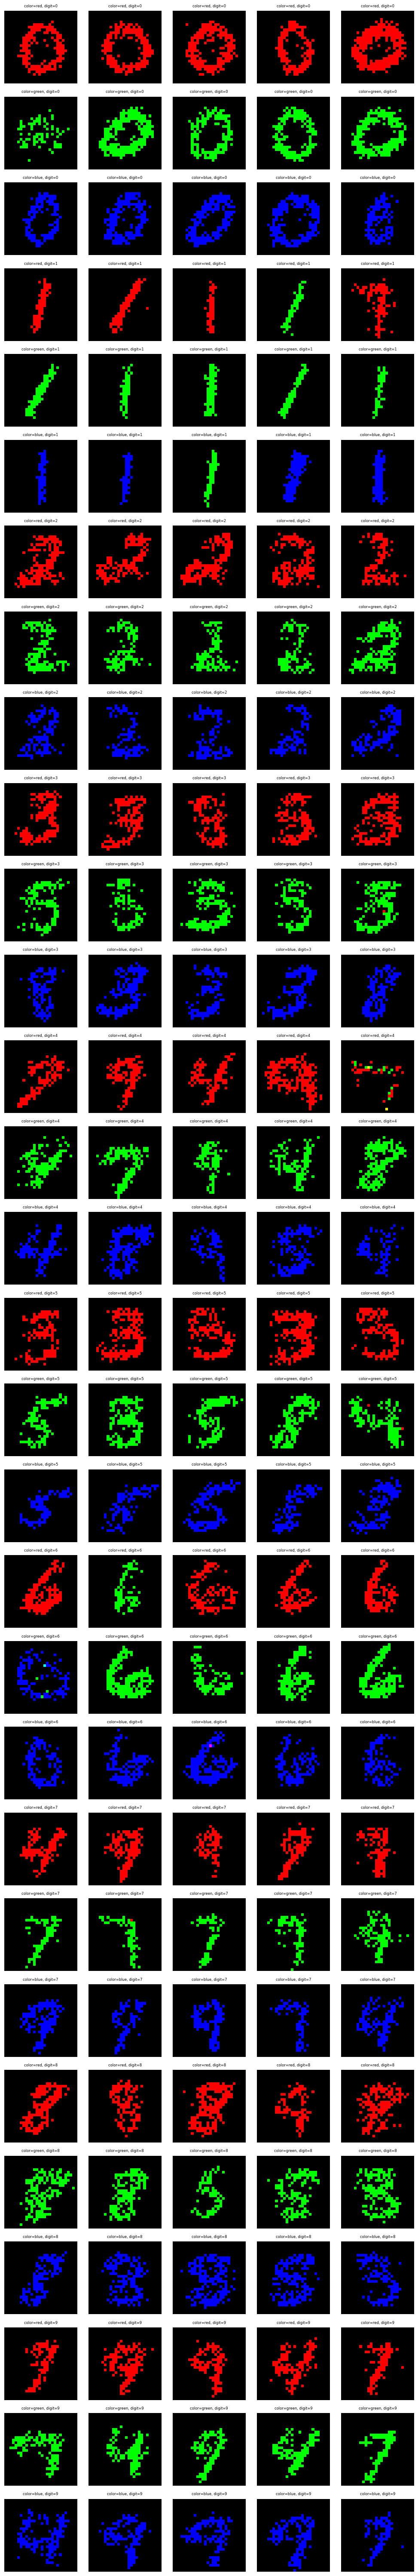

In [ ]:
# visualize reconstructions
pgm.eval()

# Each row is one digit (0–9); each column is one color (red, green, blue).
# K samples are drawn per (digit, color) tuple.
tuples = [(d, c) for d in range(10) for c in range(3)]
K = 5  # samples per tuple

digit_idx = torch.tensor([d for d, c in tuples for _ in range(K)])
color_idx  = torch.tensor([c for d, c in tuples for _ in range(K)])
digit_choices = F.one_hot(digit_idx, num_classes=10).float().to(device)
color_choices = F.one_hot(color_idx,  num_classes=3).float().to(device)
N = len(digit_idx)

output = pgm(
    data={
        'Digit': digit_choices,
        'Color': color_choices,
    }
)

images = output['Image'].view(N, 3, 28, 28).permute(0, 2, 3, 1).detach().cpu().numpy()

_color_name = {0: 'red', 1: 'green', 2: 'blue'}
n_rows = len(tuples)
fig, axes = plt.subplots(n_rows, K, figsize=(K * 2, n_rows * 2))
for row, (d, c) in enumerate(tuples):
    for col in range(K):
        ax = axes[row, col]
        ax.imshow(images[row * K + col])
        ax.set_title(f"color={_color_name[c]}, digit={d}", fontsize=6)
        ax.axis('off')
plt.tight_layout()
plt.show()

# Interactive latent-space explorer

Use the **Digit** and **Color** controls to select concepts, then drag the **Z₀ / Z₁** sliders to navigate the latent space. Click **Snap to concept mean** to jump to the expected Z location for the selected concept pair. The scatter plot shows 2 000 encoded training samples coloured by digit; the ★ marks your current Z and the ✕ marks the concept prior mean.

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

pgm.eval()

_CNAMES = ['Red', 'Green', 'Blue']

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------

def _generate_image(z0: float, z1: float, digit_val: int, color_val: int) -> np.ndarray:
    """Generate an image via the PGM with Z, Digit and Color fixed as observations."""
    with torch.no_grad():
        z     = torch.tensor([[z0, z1]], dtype=torch.float32, device=device)
        d_oh  = F.one_hot(torch.tensor([digit_val]), num_classes=10).float().to(device)
        c_oh  = F.one_hot(torch.tensor([color_val]),  num_classes=3).float().to(device)
        output = pgm(data={
            'Digit': d_oh,
            'Color': c_oh,
            'Z':     z,
        })
        img = output['Image'].view(3, 28, 28).permute(1, 2, 0)
    return img.cpu().numpy().clip(0, 1)

def _concept_z_mean(digit_val: int, color_val: int) -> np.ndarray:
    """Return the prior Z mean (loc) for a (digit, color) concept pair."""
    with torch.no_grad():
        d_oh = F.one_hot(torch.tensor([digit_val]), num_classes=10).float().to(device)
        c_oh = F.one_hot(torch.tensor([color_val]),  num_classes=3).float().to(device)
        params = cpd_z.forward(parent_values={'Digit': d_oh, 'Color': c_oh})
    return params['loc'][0].cpu().numpy()   # (2,)

def _snap_sliders_to_mean(digit_val: int, color_val: int):
    """Move Z sliders to the concept prior mean without triggering double renders."""
    zmean = _concept_z_mean(digit_val, color_val)
    z0_w.unobserve(_on_z_change, names='value')
    z1_w.unobserve(_on_z_change, names='value')
    z0_w.value = float(np.clip(zmean[0], -2.0, 2.0))
    z1_w.value = float(np.clip(zmean[1], -2.0, 2.0))
    z0_w.observe(_on_z_change, names='value')
    z1_w.observe(_on_z_change, names='value')

# ------------------------------------------------------------------
# Widgets
# ------------------------------------------------------------------

digit_w = widgets.Dropdown(
    options=[(str(i), i) for i in range(10)],
    value=0,
    description='Digit:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='180px'),
)
color_w = widgets.ToggleButtons(
    options=[('🔴 Red', 0), ('🟢 Green', 1), ('🔵 Blue', 2)],
    value=0,
    description='Color:',
    style={'button_width': '80px', 'description_width': 'initial'},
)
z0_w = widgets.FloatSlider(
    value=0.0, min=-2.0, max=2.0, step=0.05,
    description='Z₀:',
    continuous_update=True,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='380px'),
)
z1_w = widgets.FloatSlider(
    value=0.0, min=-2.0, max=2.0, step=0.05,
    description='Z₁:',
    continuous_update=True,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='380px'),
)
snap_btn = widgets.Button(
    description='Snap to concept mean',
    button_style='info',
    icon='crosshairs',
    layout=widgets.Layout(width='200px'),
)

out_img = widgets.Output()

# ------------------------------------------------------------------
# Render helpers
# ------------------------------------------------------------------

def _render_image(z0, z1, digit, color):
    img = _generate_image(z0, z1, digit, color)
    with out_img:
        out_img.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.imshow(img)
        ax.set_title(
            f'Digit: {digit}   Color: {_CNAMES[color]}\n'
            f'Z = ({z0:.2f}, {z1:.2f})',
            fontsize=9,
        )
        ax.axis('off')
        plt.tight_layout()
        plt.show()

def _render_all():
    _render_image(z0_w.value, z1_w.value, digit_w.value, color_w.value)

# ------------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------------

def _on_z_change(change=None):
    _render_all()

def _on_concept_change(change=None):
    _snap_sliders_to_mean(digit_w.value, color_w.value)
    _render_all()

def _on_snap(btn):
    _snap_sliders_to_mean(digit_w.value, color_w.value)
    _render_all()

snap_btn.on_click(_on_snap)
digit_w.observe(_on_concept_change, names='value')
color_w.observe(_on_concept_change, names='value')
z0_w.observe(_on_z_change, names='value')
z1_w.observe(_on_z_change, names='value')

# ------------------------------------------------------------------
# Layout & initial render
# ------------------------------------------------------------------
_snap_sliders_to_mean(digit_w.value, color_w.value)
_render_all()

controls = widgets.VBox(
    [digit_w, color_w,
     widgets.Label('── Latent code ──'),
     z0_w, z1_w, snap_btn],
    layout=widgets.Layout(width='410px'),
)
display(widgets.HBox([controls, out_img]))
